In [1]:
import sklearn

In [2]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('L:/Workspace/Resources/UPDATED_NLP_COURSE/TextFiles/smsspamcollection.tsv', sep='\t')

In [6]:
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


In [9]:
df.isnull().sum()

label      0
message    0
length     0
punct      0
dtype: int64

In [10]:
len(df)

5572

In [12]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

In [14]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

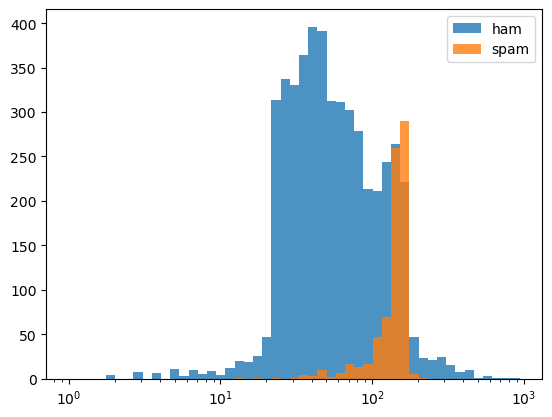

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.xscale('log')
bins = 1.15**(np.arange(0,50))
plt.hist(df[df['label']=='ham']['length'],bins=bins, alpha=0.8)
plt.hist(df[df['label']=='spam']['length'],bins=bins, alpha=0.8)
plt.legend(('ham','spam'))
plt.show()

In length wise - spam messages are longer usually than ham messages. 

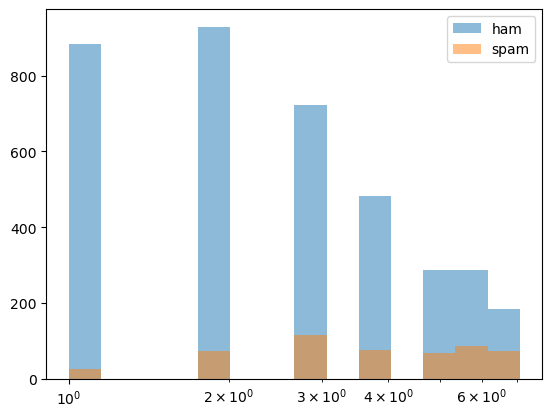

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.xscale('log')
bins = 1.15**(np.arange(0,15))
plt.hist(df[df['label']=='ham']['punct'],bins=bins, alpha=0.5)
plt.hist(df[df['label']=='spam']['punct'],bins=bins, alpha=0.5)
plt.legend(('ham','spam'))
plt.show()

ham has more puncts but its not clear different 

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x = df[['length','punct']]
y=df['label']

x_train, x_test, y_train, y_test = train_test_split(x , y, test_size=0.3, random_state=42)



In [21]:
x_train.shape

(3900, 2)

In [23]:
y_test.shape

(1672,)

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
lr = LogisticRegression()

In [27]:
lr.fit(x_train, y_train)

LogisticRegression()

In [28]:
lr_predict = lr.predict(x_test)

In [29]:
from sklearn import metrics

In [32]:
metrics.confusion_matrix(y_test , lr_predict)

array([[1404,   44],
       [ 219,    5]])

In [33]:
metrics.accuracy_score(y_test, lr_predict)

0.8427033492822966

In [34]:
metrics.classification_report(y_test, lr_predict)

'              precision    recall  f1-score   support\n\n         ham       0.87      0.97      0.91      1448\n        spam       0.10      0.02      0.04       224\n\n    accuracy                           0.84      1672\n   macro avg       0.48      0.50      0.48      1672\nweighted avg       0.76      0.84      0.80      1672\n'

So for now I can see just by using length and puncuations we will get fine results but not the best. Its best to use exact messages too 

In [35]:
from sklearn.naive_bayes import MultinomialNB

In [36]:
nb = MultinomialNB()
nb.fit(x_train, y_train)

MultinomialNB()

In [37]:
pred = nb.predict(x_test)

In [38]:
metrics.accuracy_score(y_test , pred)

0.8600478468899522

Detects 0 spam 

In [39]:
from sklearn.svm import SVC
svc = SVC(gamma='auto')

In [41]:
svc.fit(x_train, y_train)

SVC(gamma='auto')

In [42]:
pred_svc = svc.predict(x_test)

In [45]:
print(metrics.classification_report(y_test, pred_svc))

              precision    recall  f1-score   support

         ham       0.92      0.95      0.93      1448
        spam       0.58      0.46      0.51       224

    accuracy                           0.88      1672
   macro avg       0.75      0.70      0.72      1672
weighted avg       0.87      0.88      0.88      1672

